<a href="https://colab.research.google.com/github/mpaula1404/FCD_MariaPaula_MosqueraAlvarez/blob/main/proyecto_aula/py_Juan_Mosquera_Maria_Mosquera_01_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Comprensión y contextualización del problema

El objetivo principal de este análisis es explorar el comportamiento de las transacciones financieras para identificar patrones y características que distinguen las operaciones legítimas de las fraudulentas. Este proceso incluye la evaluación de la calidad de los datos y la detección de anomalías como paso previo esencial para cualquier modelado predictivo futuro.

Este proyecto se enfoca en el estudio de transacciones financieras fraudulentas en un entorno de alta concurrencia, con el propósito de comprender los patrones y factores asociados al fraude. La metodología abarca la exploración y preparación de datos, el uso de técnicas de análisis estadísticos y la visualización de gráficos para identificar distribuciones, relaciones entre variables y comportamientos atípicos. Se realizan procesos de imputación, limpieza, transformación y escalamiento de datos para mejorar la calidad y coherencia analítica. Los resultados buscan reconocer patrones de comportamiento relacionados con transacciones fraudulentas, proporcionando una base técnica y profesional para futuros sistemas inteligentes de detección de fraude financiero.



> **Pregunta de investigación:** ¿Qué patrones analíticos y anomalías estructurales caracterizan a las transacciones financieras fraudulentas en el conjunto de datos IEEE-CIS tras un proceso de preprocesamiento integral?



## 1.1. Descripción del Conjunto de Datos

Este análisis se basa en dos conjuntos de datos principales: la Tabla de Transacciones y la Tabla de Identidad.

### Tabla de Transacciones
Esta tabla contiene información detallada sobre cada transacción financiera:
*   **TransactionDT**: Diferencia de tiempo (timedelta) desde una fecha y hora de referencia específica (no es una marca de tiempo real).
*   **TransactionAMT**: Monto del pago de la transacción en USD.
*   **ProductCD**: Código de producto, que indica el tipo de producto asociado a cada transacción.
*   **card1 - card6**: Información de la tarjeta de pago, incluyendo tipo de tarjeta, categoría, banco emisor, país, entre otros detalles. (El significado exacto está enmascarado).
*   **addr**: Información de la dirección.
*   **dist**: Información de distancia.
*   **P_ and (R__) emaildomain**: Dominio de correo electrónico del comprador (P_) y del destinatario (R__).
*   **C1-C14**: Variables de conteo, como cuántas direcciones están asociadas con una tarjeta de pago. (El significado exacto está enmascarado).
*   **D1-D15**: Diferencias de tiempo (timedelta), como los días transcurridos desde la transacción anterior.
*   **M1-M9**: Variables de coincidencia, que indican si los nombres en la tarjeta y la dirección, entre otros, coinciden.
*   **Vxxx**: Características ricas diseñadas por Vesta, que incluyen rankings, conteos y otras relaciones de entidades. (El significado exacto está enmascarado).
*   **Categorical Features**: `ProductCD`, `card1 - card6`, `addr1`, `addr2`, `P_emaildomain`, `R_emaildomain`, `M1 - M9`.

### Tabla de Identidad
Esta tabla contiene información de identidad, como detalles de conexión de red (IP, ISP, Proxy, etc.) y firma digital (UA/navegador/SO/versión, etc.) asociadas con las transacciones. Estos datos son recolectados por el sistema de protección contra fraude de Vesta y sus socios de seguridad digital. (Los nombres de los campos están enmascarados y no se proporcionará un diccionario de pares por razones de privacidad y acuerdos contractuales).
*   **Categorical Features**: `DeviceType`, `DeviceInfo`, `id_12 - id_38`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carga de los conjuntos de datos
train_identity = pd.read_csv('data/train_identity.csv')
train_transaction = pd.read_csv('data/train_transaction.csv')

# Unión de los conjuntos de datos mediante 'TransactionID'
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

# Verificación de dimensiones y visualización inicial
print('Dimensiones del DataFrame consolidado:', df.shape)
display(df.head())

Dimensiones del DataFrame consolidado: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
print(df['isFraud'].value_counts(normalize=True))


isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [ ]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 590540
Número de variables: 434


In [ ]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
float64    399
object      31
int64        4
Name: count, dtype: int64


In [ ]:
# 1. Selección de variables clave para el análisis
cols_principales = ['isFraud', 'TransactionAmt', 'ProductCD', 'card4', 'card6', 'P_emaildomain']

# 2. Agrupación de variables anónimas por prefijo técnico
cols_C = [c for c in df.columns if c.startswith('C')]
cols_D = [c for c in df.columns if c.startswith('D')]
cols_M = [c for c in df.columns if c.startswith('M')]
cols_V = [c for c in df.columns if c.startswith('V')]

print(f"Variables C: {len(cols_C)} | D: {len(cols_D)} | M: {len(cols_M)} | V: {len(cols_V)}")

Variables C: 14 | D: 17 | M: 9 | V: 339


# 2. Análisis exploratorio de datos (EDA)

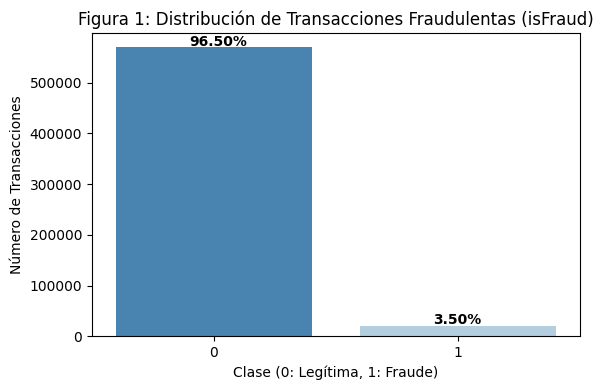

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='isFraud', data=df, palette='Blues_r')
plt.title('Figura 1: Distribución de Transacciones Fraudulentas (isFraud)', fontsize=12)
plt.xlabel('Clase (0: Legítima, 1: Fraude)')
plt.ylabel('Número de Transacciones')

# Inclusión de etiquetas de porcentaje
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + (total * 0.005)
    ax.annotate(percentage, (x, y), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figura1_desbalance.png', dpi=300)
plt.show()

print(df['isFraud'].value_counts())

## 2.1. Análisis univariado

### Análisis Univariado de `TransactionDT`

Vamos a realizar un análisis univariado de la variable `TransactionDT` para entender su distribución temporal. Esto nos permitirá identificar patrones, picos o anomalías en el tiempo de las transacciones.

In [ ]:
from scipy.stats import skew, kurtosis

# Extracción de la variable temporal
muestra_dt = df['TransactionDT']

# Cálculo de estadísticos descriptivos y de forma
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionDT: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionDT: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionDT: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionDT: {curtosis_dt:.2f}")

Media de TransactionDT: 7372311.31
Desviación Estándar de TransactionDT: 4617219.74
Asimetría de TransactionDT: 0.13
Curtosis de TransactionDT: -1.23


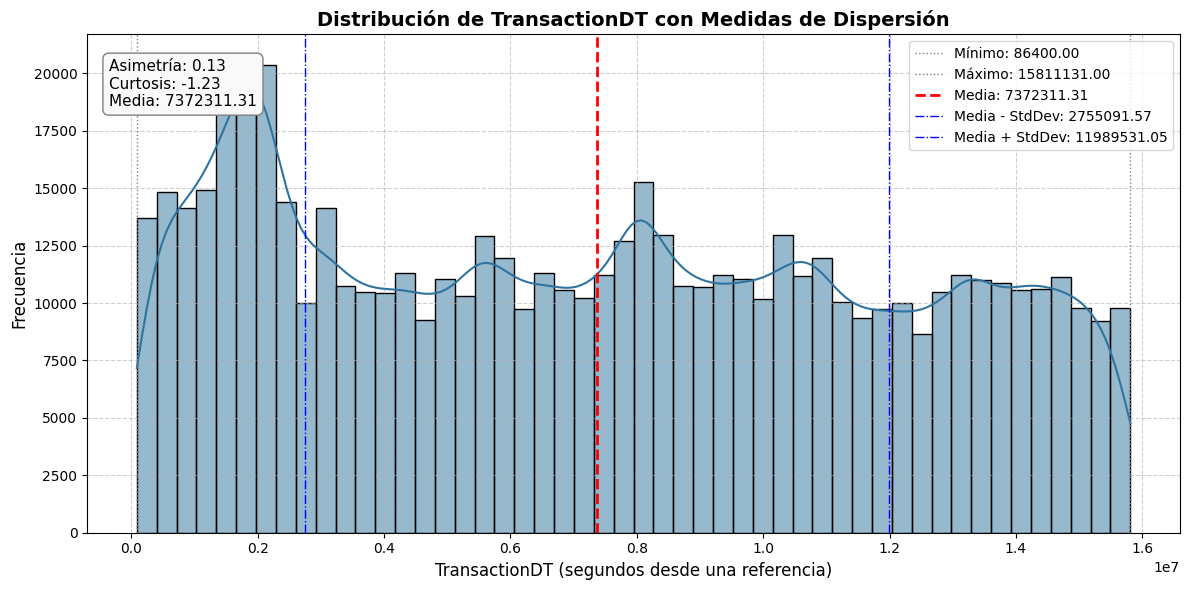

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(muestra_dt, bins=50, kde=True, color="#2F749F")

plt.axvline(np.min(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Mínimo: {np.min(muestra_dt):.2f}')
plt.axvline(np.max(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Máximo: {np.max(muestra_dt):.2f}')
plt.axvline(media_dt, color='red', linestyle='--', linewidth=2, label=f'Media: {media_dt:.2f}')

# Desviación estándar a partir de la media
plt.axvline(media_dt - desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media - StdDev: {(media_dt - desviacion_estandar_dt):.2f}')
plt.axvline(media_dt + desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media + StdDev: {(media_dt + desviacion_estandar_dt):.2f}')

plt.title("Distribución de TransactionDT con Medidas de Dispersión", fontsize=14, fontweight='bold')
plt.xlabel("TransactionDT (segundos desde una referencia)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.text(0.02, 0.95,
            f"Asimetría: {asimetria_dt:.2f}\nCurtosis: {curtosis_dt:.2f}\nMedia: {media_dt:.2f}",
            transform=plt.gca().transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="gray"))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###Análisis Univariado de `TransactionAmt`

In [ ]:
from scipy.stats import skew, kurtosis

# Extracción de la variable de monto de transacción
muestra_dt = df['TransactionAmt']

# Cálculo de estadísticos descriptivos
media_dt = np.mean(muestra_dt)
desviacion_estandar_dt = np.std(muestra_dt)
asimetria_dt = skew(muestra_dt)
curtosis_dt = kurtosis(muestra_dt, fisher=True)

print(f"Media de TransactionAmt: {media_dt:.2f}")
print(f"Desviación Estándar de TransactionAmt: {desviacion_estandar_dt:.2f}")
print(f"Asimetría de TransactionAmt: {asimetria_dt:.2f}")
print(f"Curtosis de TransactionAmt: {curtosis_dt:.2f}")

Media de TransactionAmt: 135.03
Desviación Estándar de TransactionAmt: 239.16
Asimetría de TransactionAmt: 14.37
Curtosis de TransactionAmt: 1123.95


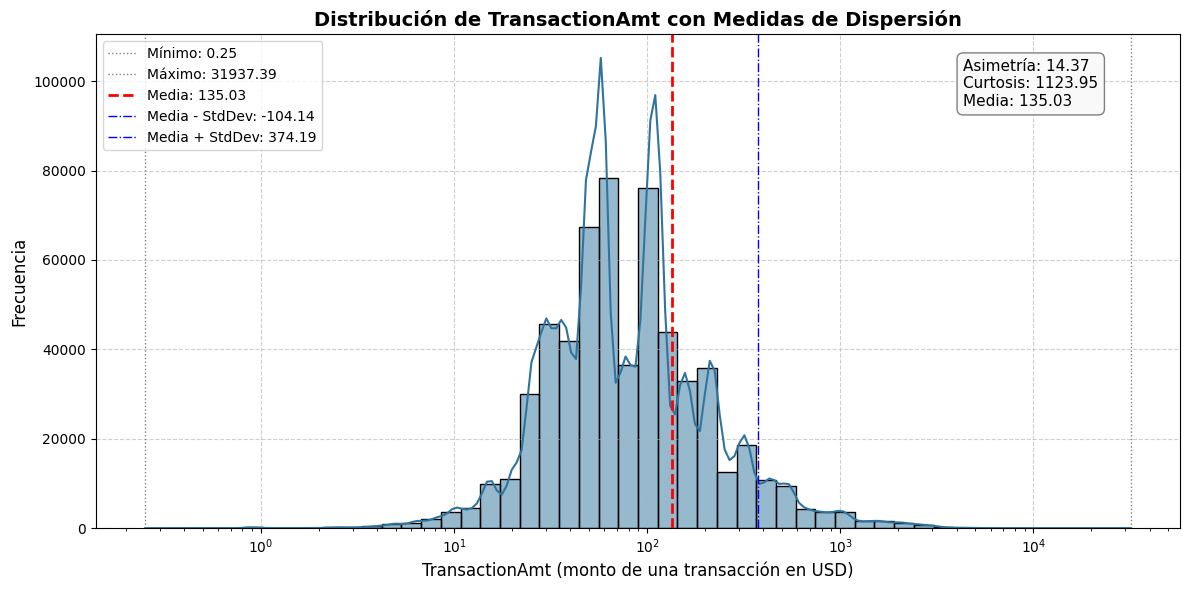

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(muestra_dt, bins=50, kde=True, color="#2F749F", log_scale=True)

plt.axvline(np.min(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Mínimo: {np.min(muestra_dt):.2f}')
plt.axvline(np.max(muestra_dt), color='gray', linestyle=':', linewidth=1, label=f'Máximo: {np.max(muestra_dt):.2f}')
plt.axvline(media_dt, color='red', linestyle='--', linewidth=2, label=f'Media: {media_dt:.2f}')

# Desviación estándar a partir de la media
plt.axvline(media_dt - desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media - StdDev: {(media_dt - desviacion_estandar_dt):.2f}')
plt.axvline(media_dt + desviacion_estandar_dt, color='blue', linestyle='-.', linewidth=1, label=f'Media + StdDev: {(media_dt + desviacion_estandar_dt):.2f}')

plt.title("Distribución de TransactionAmt con Medidas de Dispersión", fontsize=14, fontweight='bold')
plt.xlabel("TransactionAmt (monto de una transacción en USD)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.text(0.8, 0.95,
            f"Asimetría: {asimetria_dt:.2f}\nCurtosis: {curtosis_dt:.2f}\nMedia: {media_dt:.2f}",
            transform=plt.gca().transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="gray"))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2.2. Análisis bivariado

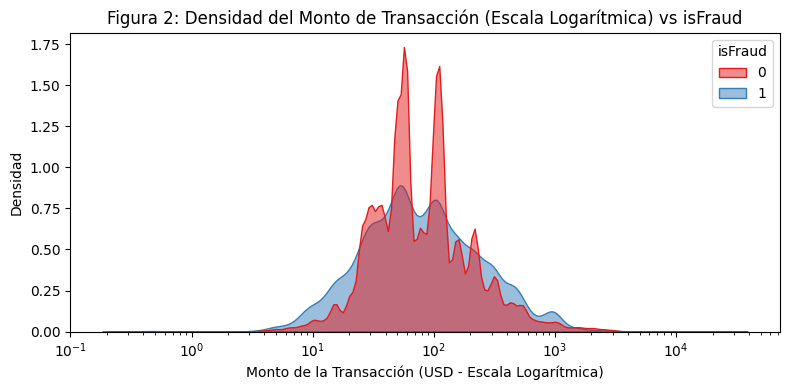

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='TransactionAmt', hue='isFraud', fill=True, common_norm=False, palette='Set1', log_scale=True, alpha=0.5)
plt.title('Figura 2: Densidad del Monto de Transacción (Escala Logarítmica) vs isFraud', fontsize=12)
plt.xlabel('Monto de la Transacción (USD - Escala Logarítmica)')
plt.ylabel('Densidad')
plt.tight_layout()
#plt.savefig('figura2_monto_density.png', dpi=300)
plt.show()

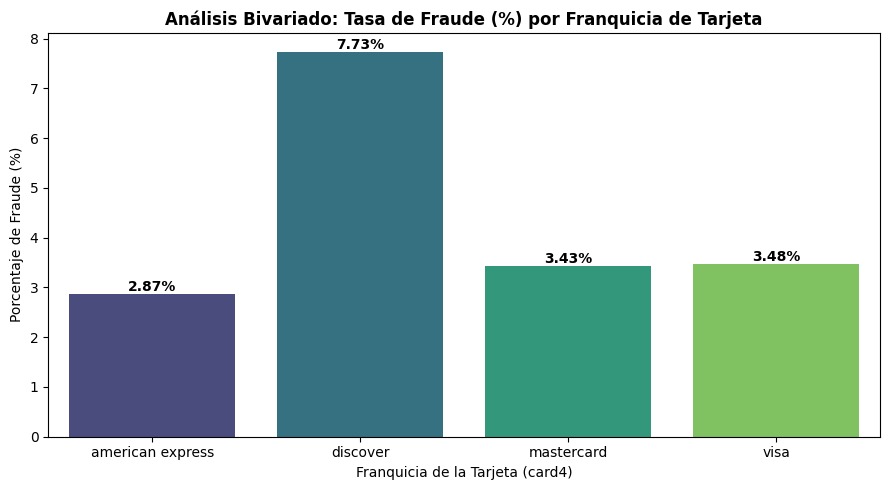

In [ ]:
plt.figure(figsize=(9, 5))

# Cálculo de la tasa de fraude relativa por franquicia
tasa_fraude_card = df.groupby('card4')['isFraud'].mean().reset_index()
tasa_fraude_card['isFraud'] = tasa_fraude_card['isFraud'] * 100

ax = sns.barplot(data=tasa_fraude_card, x='card4', y='isFraud', palette='viridis')

plt.title('Análisis Bivariado: Tasa de Fraude (%) por Franquicia de Tarjeta', fontsize=12, fontweight='bold')
plt.xlabel('Franquicia de la Tarjeta (card4)')
plt.ylabel('Porcentaje de Fraude (%)')

# Inclusión de etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('bivariado_tarjeta_fraud.png', dpi=300)
plt.show()

'MasterCard' (2.96%) y 'Discover' (2.62%) presentan proporciones de fraude ligeramente superiores en comparación con 'Visa' (2.51%) y 'American Express' (0.99%). Estas diferencias, aunque menores, podrían indicar variaciones en los métodos de seguridad o el perfil de riesgo asociado a cada franquicia.

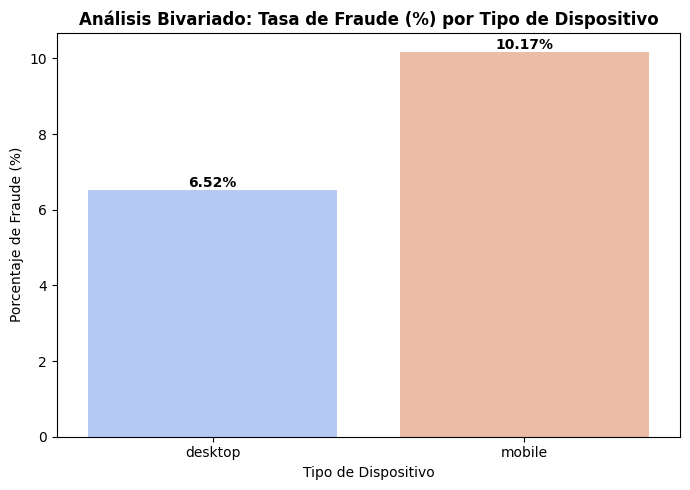

In [ ]:
if 'DeviceType' in df.columns:
    plt.figure(figsize=(7, 5))

    # Cálculo de la tasa de fraude por tipo de dispositivo
    tasa_fraude_device = df.groupby('DeviceType')['isFraud'].mean().reset_index()
    tasa_fraude_device['isFraud'] = tasa_fraude_device['isFraud'] * 100

    ax = sns.barplot(data=tasa_fraude_device, x='DeviceType', y='isFraud', palette='coolwarm')

    plt.title('Análisis Bivariado: Tasa de Fraude (%) por Tipo de Dispositivo', fontsize=12, fontweight='bold')
    plt.xlabel('Tipo de Dispositivo')
    plt.ylabel('Porcentaje de Fraude (%)')

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('bivariado_dispositivo_fraud.png', dpi=300)
    plt.show()



El gráfico de barras para la tasa de fraude por `DeviceType` revela
que los dispositivos móviles (`Mobile`) presentan una tasa de fraude considerablemente más alta que los dispositivos `Desktop`. Esto podría deberse a varios factores, como una menor seguridad en dispositivos móviles, la facilidad para realizar transacciones rápidas que pueden ser explotadas por estafadores, o patrones de uso que favorecen el fraude.



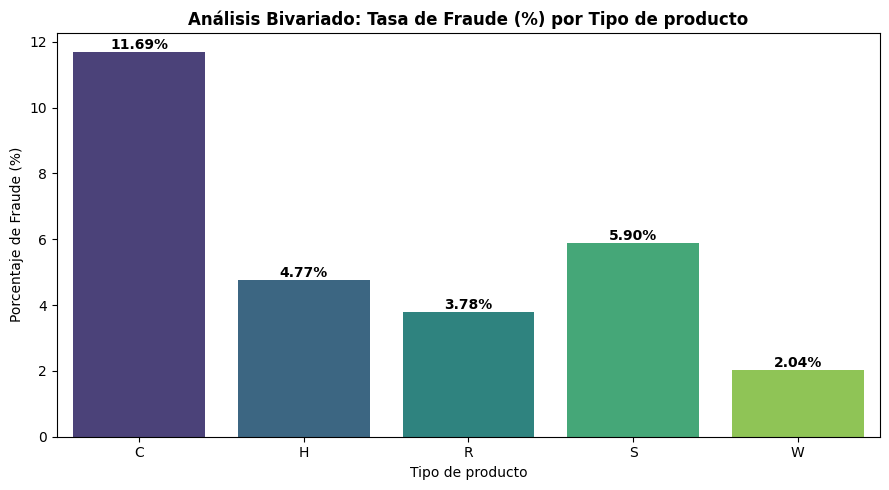

In [ ]:
plt.figure(figsize=(9, 5))

# Calcular la tasa de fraude promedio por cada producto
tasa_fraude_card = df.groupby('ProductCD')['isFraud'].mean().reset_index()
# Convertir a porcentaje
tasa_fraude_card['isFraud'] = tasa_fraude_card['isFraud'] * 100

ax = sns.barplot(data=tasa_fraude_card, x='ProductCD', y='isFraud', palette='viridis')

plt.title('Análisis Bivariado: Tasa de Fraude (%) por Tipo de producto', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de producto')
plt.ylabel('Porcentaje de Fraude (%)')

# Añadir las etiquetas de porcentaje sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('bivariado_tarjeta_fraud.png', dpi=300)
plt.show()

Se observa una clara predominancia del fraude en ciertas categorías de productos. Por ejemplo, los códigos 'S' y 'C' muestran una cantidad significativa de transacciones fraudulentas, siendo la categoría 'C' particularmente crítica ya que un alto porcentaje de sus transacciones son fraude, indicando que el tipo de producto puede ser un factor discriminante fuerte.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Preparación de datos para la prueba de independencia
df_chi = df[['DeviceType', 'isFraud']].dropna()

print(f"Registros evaluados para la prueba: {len(df_chi)}")

# 1. Generación de la tabla de contingencia
tabla_contingencia = pd.crosstab(df_chi['DeviceType'], df_chi['isFraud'])
print("\n--- TABLA DE CONTINGENCIA ---")
print(tabla_contingencia)

# 2. Ejecución de la prueba Chi-cuadrado
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)

# 3. Cálculo de la V de Cramer para medir el tamaño del efecto
n = tabla_contingencia.sum().sum()
min_dimension = min(tabla_contingencia.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dimension))

print("\n--- RESULTADOS ESTADÍSTICOS ---")
print(f"Estadístico Chi-cuadrado (χ²): {chi2:.4f}")
print(f"P-valor: {p:.4e}")
print(f"V de Cramer: {v_cramer:.4f}")

# Interpretación de resultados
alpha = 0.05
if p < alpha:
    print("\nConclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.")
else:
    print("\nConclusión: No se rechaza H0. No hay evidencia de relación estadística.")

Registros evaluados para la prueba: 140810

--- TABLA DE CONTINGENCIA ---
isFraud         0     1
DeviceType             
desktop     79611  5554
mobile      49988  5657

--- RESULTADOS ESTADÍSTICOS ---
Estadístico Chi-cuadrado (χ²): 609.6238
P-valor: 1.3508e-134
V de Cramer: 0.0658

Conclusión: Se rechaza H0. Existe una relación significativa entre el Tipo de Dispositivo y el Fraude.


## 2.3. Análisis multivariado

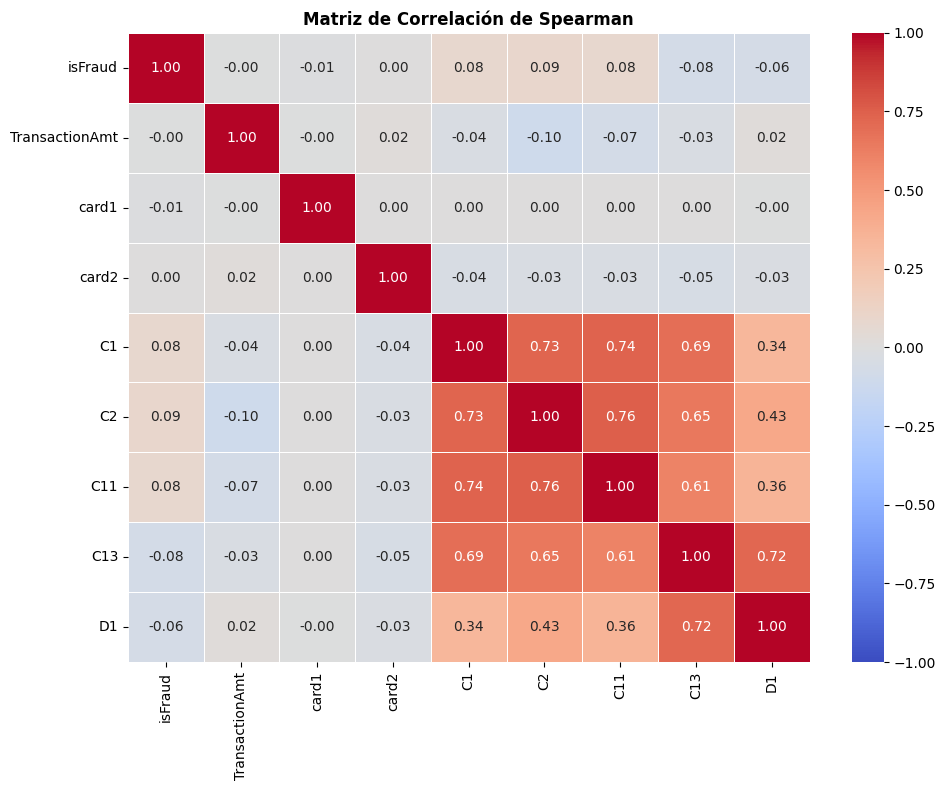

Correlación de Spearman respecto a isFraud:
isFraud           1.000000
C2                0.089504
C11               0.078989
C1                0.078593
card2             0.003516
TransactionAmt   -0.001576
card1            -0.013431
D1               -0.063984
C13              -0.075038
Name: isFraud, dtype: float64


In [ ]:
# Selección de variables numéricas relevantes para el análisis de correlación
columnas_interes = ['isFraud', 'TransactionAmt', 'card1', 'card2', 'C1', 'C2', 'C11', 'C13', 'D1']
columnas_interes = [c for c in columnas_interes if c in df.columns]

# Cálculo de la matriz de correlación de Spearman
df_spearman = df[columnas_interes].corr(method='spearman')

# Visualización mediante mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(df_spearman, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlación de Spearman', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_spearman.png', dpi=300)
plt.show()

# Ranking de correlación respecto a la variable objetivo
print("Correlación de Spearman respecto a isFraud:")
print(df_spearman['isFraud'].sort_values(ascending=False))

--- INICIANDO DIAGNÓSTICO DE REDUNDANCIA POR SUBGRUPOS (SPEARMAN) ---


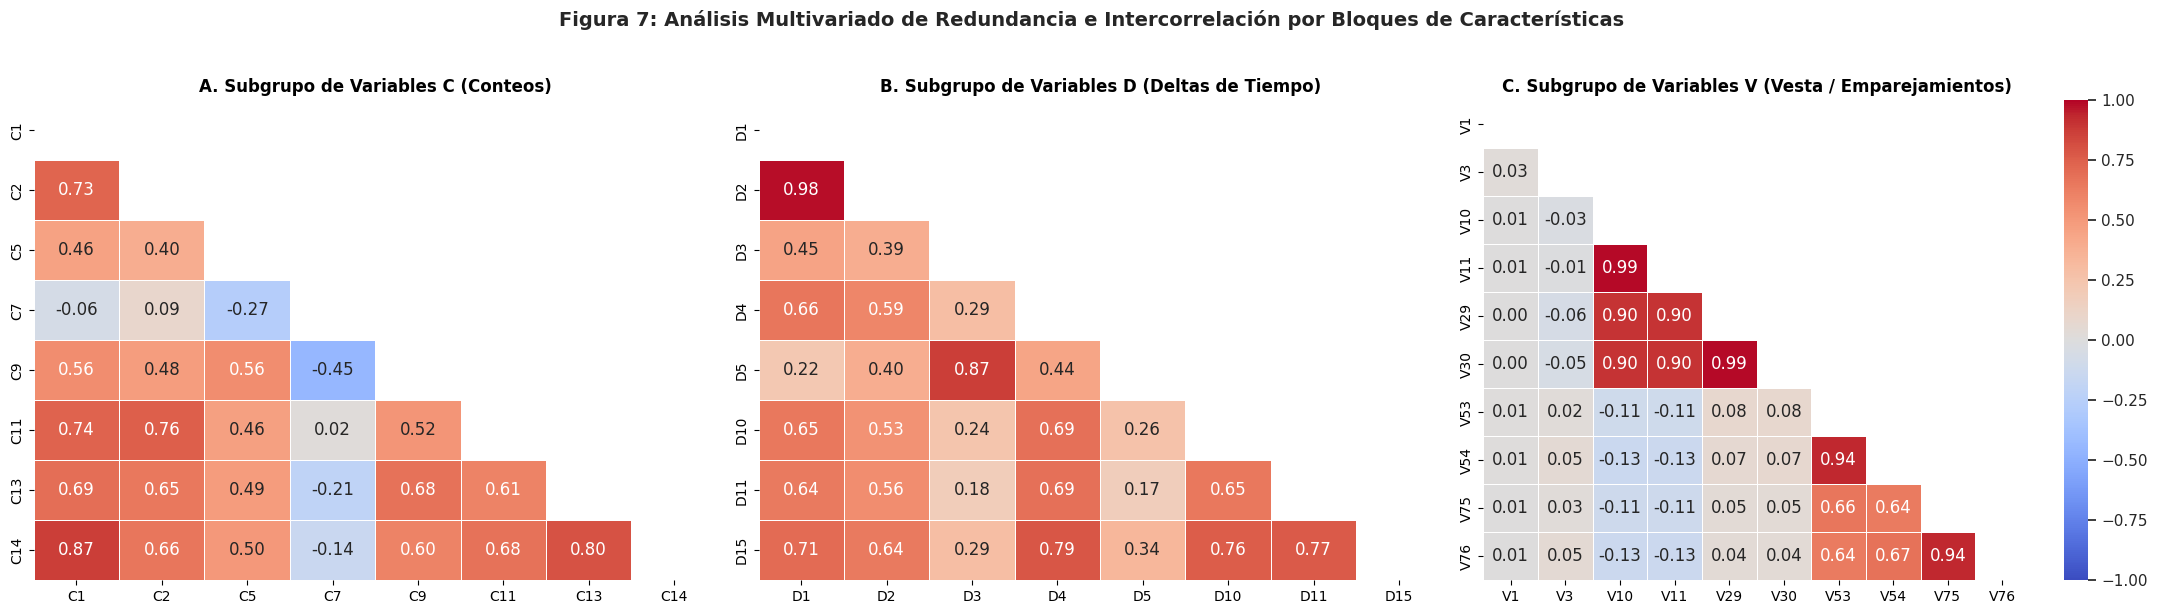


 Redundancias Críticas en Bloque C (|r_s| > 0.85):
  * C14 <-> C1 : Correlación = 0.8730

 Redundancias Críticas en Bloque D (|r_s| > 0.85):
  * D2 <-> D1 : Correlación = 0.9800
  * D5 <-> D3 : Correlación = 0.8741

 Redundancias Críticas en Bloque V (|r_s| > 0.85):
  * V11 <-> V10 : Correlación = 0.9917
  * V29 <-> V10 : Correlación = 0.9028
  * V29 <-> V11 : Correlación = 0.9006
  * V30 <-> V10 : Correlación = 0.9023
  * V30 <-> V11 : Correlación = 0.9042
  * V30 <-> V29 : Correlación = 0.9907
  * V54 <-> V53 : Correlación = 0.9369
  * V76 <-> V75 : Correlación = 0.9354


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INICIANDO DIAGNÓSTICO DE REDUNDANCIA POR SUBGRUPOS (SPEARMAN) ---")

# 1. Definición de subgrupos representativos basados en la arquitectura del dataset
subgrupo_C = ['C1', 'C2', 'C5', 'C7', 'C9', 'C11', 'C13', 'C14']
subgrupo_D = ['D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']
subgrupo_V = ['V1', 'V3', 'V10', 'V11', 'V29', 'V30', 'V53', 'V54', 'V75', 'V76']

# Validar que las columnas existan en el DataFrame antes de indexar
subgrupo_C = [c for c in subgrupo_C if c in df.columns]
subgrupo_D = [d for d in subgrupo_D if d in df.columns]
subgrupo_V = [v for v in subgrupo_V if v in df.columns]

# 2. Configuración de la figura compuesta (3 Subplots en línea)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_theme(style="white")

# --- SUBGRUPO C: Frecuencias y Conteos ---
corr_C = df[subgrupo_C].corr(method='spearman')
mask_C = np.triu(np.ones_like(corr_C, dtype=bool))
sns.heatmap(corr_C, mask=mask_C, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title('A. Subgrupo de Variables C (Conteos)', fontsize=12, fontweight='bold')

# --- SUBGRUPO D: Deltas Temporales ---
corr_D = df[subgrupo_D].corr(method='spearman')
mask_D = np.triu(np.ones_like(corr_D, dtype=bool))
sns.heatmap(corr_D, mask=mask_D, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title('B. Subgrupo de Variables D (Deltas de Tiempo)', fontsize=12, fontweight='bold')

# --- SUBGRUPO V: Atributos Vesta ---
corr_V = df[subgrupo_V].corr(method='spearman')
mask_V = np.triu(np.ones_like(corr_V, dtype=bool))
sns.heatmap(corr_V, mask=mask_V, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[2], cbar=True, linewidths=0.5)
axes[2].set_title('C. Subgrupo de Variables V (Vesta / Emparejamientos)', fontsize=12, fontweight='bold')

plt.suptitle('Figura 7: Análisis Multivariado de Redundancia e Intercorrelación por Bloques de Características',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matriz_redundancia_subgrupos.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Reporte de pares con colinealidad crítica (> 0.85)
def reportar_redundancias(df_sub, nombre_bloque):
    corr_mat = df_sub.corr(method='spearman').abs()
    upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    pares_criticos = [(column, row, upper_tri.loc[row, column])
                      for column in upper_tri.columns for row in upper_tri.index
                      if upper_tri.loc[row, column] > 0.85]

    print(f"\n Redundancias Críticas en {nombre_bloque} (|r_s| > 0.85):")
    if pares_criticos:
        for var1, var2, val in pares_criticos:
            print(f"  * {var1} <-> {var2} : Correlación = {val:.4f}")
    else:
        print("  * No se detectaron redundancias críticas en el subgrupo evaluado.")

reportar_redundancias(df[subgrupo_C], "Bloque C")
reportar_redundancias(df[subgrupo_D], "Bloque D")
reportar_redundancias(df[subgrupo_V], "Bloque V")

# 3. Detección de atípicos

--- DIAGNÓSTICO DE VALORES ATÍPICOS ---


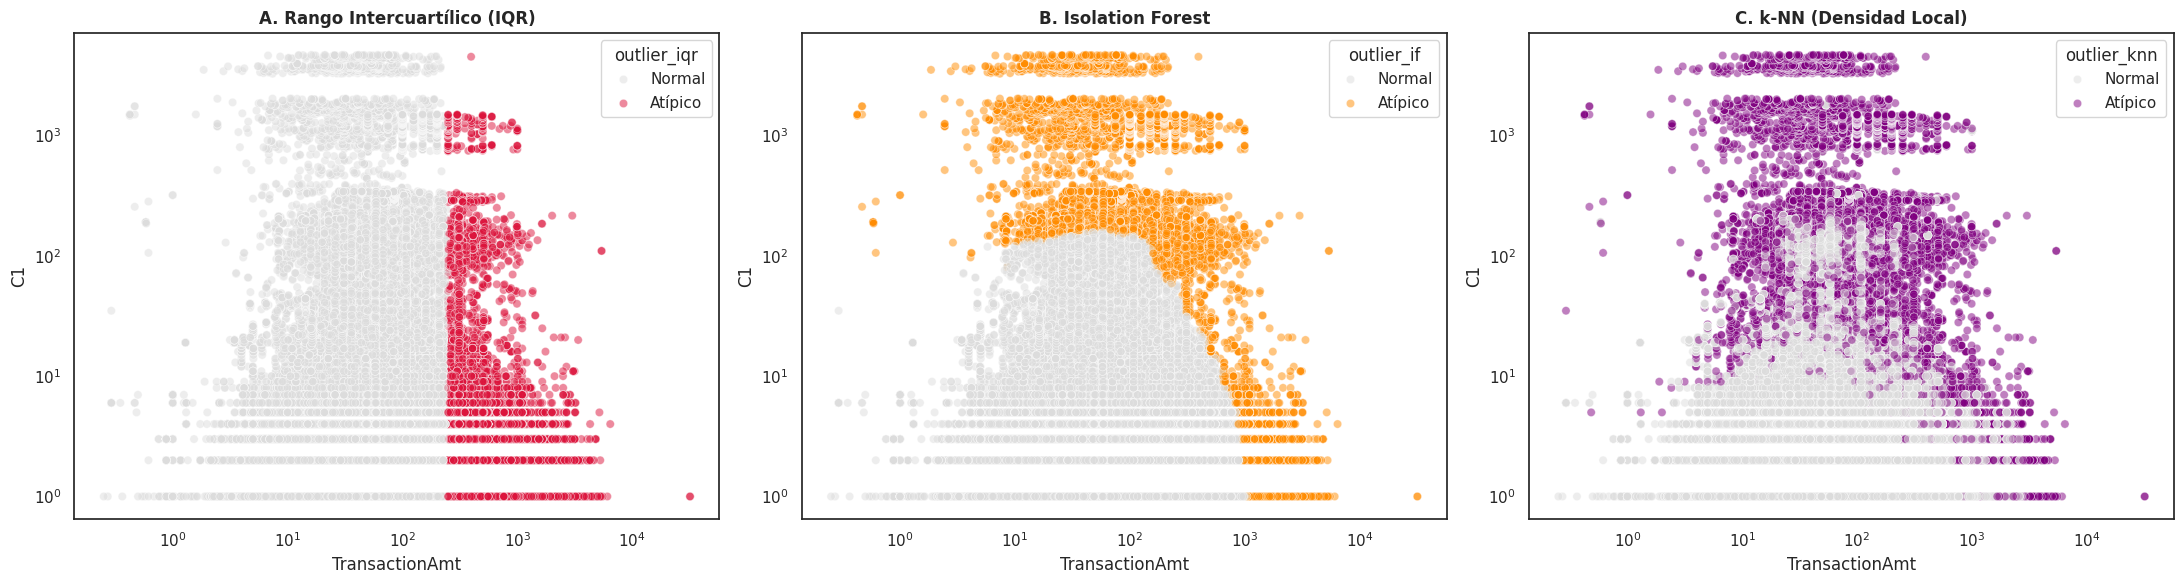

IQR: detectó 3372 fraudes verdaderos.
Isolation Forest: detectó 1168 fraudes verdaderos.
k-NN: detectó 1987 fraudes verdaderos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors

print("--- DIAGNÓSTICO DE VALORES ATÍPICOS ---")

# Preparación del subconjunto de datos
df_subset_atipicos = df[['TransactionAmt', 'C1', 'isFraud']].dropna().copy()
X_atipicos = df_subset_atipicos[['TransactionAmt', 'C1']]
y_real = df_subset_atipicos['isFraud']

# MÉTODO 1: Rango Intercuartílico (IQR)
Q1 = X_atipicos['TransactionAmt'].quantile(0.25)
Q3 = X_atipicos['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1
limite_superior_iqr = Q3 + (1.5 * IQR)
df_subset_atipicos['outlier_iqr'] = np.where(X_atipicos['TransactionAmt'] > limite_superior_iqr, 'Atípico', 'Normal')

# MÉTODO 2: Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
df_subset_atipicos['outlier_if'] = np.where(iso_forest.fit_predict(X_atipicos) == -1, 'Atípico', 'Normal')

# MÉTODO 3: k-Nearest Neighbors (k-NN)
knn = NearestNeighbors(n_neighbors=5, n_jobs=-1)
knn.fit(X_atipicos)
distancias, _ = knn.kneighbors(X_atipicos)
df_subset_atipicos['knn_score'] = distancias.mean(axis=1)
umbral_knn = df_subset_atipicos['knn_score'].quantile(0.97)
df_subset_atipicos['outlier_knn'] = np.where(df_subset_atipicos['knn_score'] > umbral_knn, 'Atípico', 'Normal')

# Visualización comparativa de métodos
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_theme(style="whitegrid")

# Graficación por método
for i, (metodo, col, titulo) in enumerate([
    ('outlier_iqr', 'crimson', 'A. Rango Intercuartílico (IQR)'),
    ('outlier_if', 'darkorange', 'B. Isolation Forest'),
    ('outlier_knn', 'purple', 'C. k-NN (Densidad Local)')
]):
    sns.scatterplot(ax=axes[i], x='TransactionAmt', y='C1', hue=metodo,
                    data=df_subset_atipicos, palette={'Normal': 'gainsboro', 'Atípico': col}, alpha=0.5)
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(titulo, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('comparativa_tecnicas_atipicos.png', dpi=300)
plt.show()

# Evaluación de efectividad respecto a fraudes reales
for metodo, col in [('IQR', 'outlier_iqr'), ('Isolation Forest', 'outlier_if'), ('k-NN', 'outlier_knn')]:
    fraudes_atrapados = df_subset_atipicos[(df_subset_atipicos[col] == 'Atípico') & (y_real == 1)].shape[0]
    print(f"{metodo}: detectó {fraudes_atrapados} fraudes verdaderos.")

# 4. Imputación de valores nulos y transformación

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

print("--- ESTRATEGIA DE IMPUTACIÓN CON KNN AL 30% ---")

df_clean = df.copy()

# 1. Identificación de outliers mediante k-NN (Mantenemos la lógica de indicadores)
df_temporal_knn = df_clean[['TransactionAmt', 'C1']].dropna()
knn_detector = NearestNeighbors(n_neighbors=5, n_jobs=-1)
knn_detector.fit(df_temporal_knn)
distancias, _ = knn_detector.kneighbors(df_temporal_knn)
umbral_knn = np.percentile(distancias.mean(axis=1), 97)

nuevas_cols = {}
ser_outliers = pd.Series(np.where(distancias.mean(axis=1) > umbral_knn, 1, 0), index=df_temporal_knn.index)
nuevas_cols['is_outlier_knn'] = df_clean.index.map(ser_outliers).fillna(0)

for col in ['DeviceType', 'id_31']:
    if col in df_clean.columns: nuevas_cols[f'{col}_was_null'] = df_clean[col].isnull().astype(int)
df_clean = df_clean.assign(**nuevas_cols)

# 2. Imputación Progresiva: KNN solo al 30% de la muestra para ahorrar RAM
cols_knn = [c for c in ['TransactionAmt', 'C1', 'C2', 'C13', 'D1', 'D15'] if c in df_clean.columns]

# Seleccionamos aleatoriamente el 30% de los índices
np.random.seed(42)
indices_para_knn = df_clean.sample(frac=0.3).index

# Separamos el subconjunto para KNN
df_sub_knn = df_clean.loc[indices_para_knn, cols_knn].copy()
scaler_mm = MinMaxScaler()
data_scaled = scaler_mm.fit_transform(df_sub_knn)

print(f" -> Ejecutando KNNImputer sobre {len(indices_para_knn)} registros (30% del total)... ")
imputer = KNNImputer(n_neighbors=5)
df_clean.loc[indices_para_knn, cols_knn] = scaler_mm.inverse_transform(imputer.fit_transform(data_scaled))

# 3. Imputación Base para el resto de datos y columnas
# (Mediana para numéricos y 'Unknown' para categóricos)
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col != 'isFraud':
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in df_clean.select_dtypes(exclude=[np.number]).columns:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 4. Normalización final
scaler_std = StandardScaler()
df_clean['TransactionAmt_scaled'] = scaler_std.fit_transform(df_clean[['TransactionAmt']])

print(f"Nulos finales: {df_clean.isnull().sum().sum()} | Dimensiones: {df_clean.shape}")

--- ESTRATEGIA DE IMPUTACIÓN CON KNN AL 30% ---
 -> Ejecutando KNNImputer sobre 177162 registros (30% del total)... 
Nulos finales: 0 | Dimensiones: (590540, 438)


### 4.1. Codificación de Variables Categóricas (Label Encoding)

In [ ]:
# Verificación del estado de las variables categóricas tras la limpieza
cat_cols = df_clean.select_dtypes(include=['object']).columns

print(f"Número de variables categóricas: {len(cat_cols)}")
print("\nEjemplo de valores en variables clave:")
for col in ['ProductCD', 'card4', 'card6', 'DeviceType']:
    if col in df_clean.columns:
        print(f"{col}: {df_clean[col].unique()[:5]}")

# Mostrar tipos de datos actuales
print("\nTipos de datos actuales:")
display(df_clean[cat_cols].dtypes.head(10))

Número de variables categóricas: 31

Ejemplo de valores en variables clave:
ProductCD: ['W' 'H' 'C' 'S' 'R']
card4: ['discover' 'mastercard' 'visa' 'american express' 'Unknown']
card6: ['credit' 'debit' 'Unknown' 'debit or credit' 'charge card']
DeviceType: ['Unknown' 'mobile' 'desktop']

Tipos de datos actuales:


,0
ProductCD,object
card4,object
card6,object
P_emaildomain,object
R_emaildomain,object
M1,object
M2,object
M3,object
M4,object
M5,object


In [ ]:
from sklearn.preprocessing import LabelEncoder

print("--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---")

# Identificación de columnas categóricas
cat_cols = df_clean.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in cat_cols:
    # Aplicamos LabelEncoder transformando cada categoría a un entero
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f"Codificación completada. {len(cat_cols)} variables transformadas.")
print(f"Dimensiones finales del dataset: {df_clean.shape}")

# Verificación de que ya no existan columnas tipo 'object'
print("\nDistribución de tipos de datos actual:")
print(df_clean.dtypes.value_counts())

display(df_clean[cat_cols].head())

--- INICIANDO CODIFICACIÓN DE CATEGORÍAS ---
Codificación completada. 31 variables transformadas.
Dimensiones finales del dataset: (590540, 438)

Distribución de tipos de datos actual:
float64    400
int64       38
Name: count, dtype: int64


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4,2,2,0,0,1,1,1,2,0,...,41,14,260,0,2,2,2,2,0,1557
1,4,3,2,17,0,2,2,2,0,1,...,41,14,260,0,2,2,2,2,0,1557
2,4,4,3,36,0,1,1,1,0,0,...,41,14,260,0,2,2,2,2,0,1557
3,4,3,3,54,0,2,2,2,0,1,...,41,14,260,0,2,2,2,2,0,1557
4,1,3,2,17,0,2,2,2,3,2,...,7,124,164,4,1,0,1,1,2,954


### 4.2. Exportación del Dataset Final

In [ ]:
# Exportación a CSV
nombre_archivo = 'data/train_final_preprocessed.csv'

try:
    df_clean.to_csv(nombre_archivo, index=False)
    print(f"--- EXPORTACIÓN EXITOSA ---")
    print(f"Archivo guardado en: {nombre_archivo}")
    print(f"Registros: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")
except Exception as e:
    print(f"Error al guardar el archivo: {e}")
    # Intento de guardado en el directorio raíz si 'data/' no es accesible
    df_clean.to_csv('train_final_preprocessed.csv', index=False)
    print("Archivo guardado en el directorio raíz como 'train_final_preprocessed.csv'")

--- EXPORTACIÓN EXITOSA ---
Archivo guardado en: data/train_final_preprocessed.csv
Registros: 590540 | Columnas: 438
